# Apprentissage supervisé sur de vraies classes (« oracle »)

Jusqu'ici (`apprentissage_mat_sur_kmeans.ipynb`, `apprentissage_por_kmeans.ipynb`), on a prédit des **clusters K-means** —
des classes *artificielles*, construites par un algorithme non supervisé pour maximiser la séparation dans l'espace ACP.

Ici on change de paradigme : on prédit de **vraies variables du dataset** (vérité terrain / « oracle »), pas une étiquette
qu'on a nous-mêmes fabriquée. L'idée :
- réutiliser toute la méthodologie déjà rodée (sélection ANOVA, vérification des hypothèses, KNN / LDA / QDA / Régression logistique)
- voir si elle se comporte différemment sur de vraies classes
- en tirer des conclusions sur la nature des clusters K-means : étaient-ils « trop faciles » à prédire parce qu'ils étaient
  géométriquement optimisés pour ça, ou révèlent-ils une vraie structure comportementale ?

## Cibles retenues

| Variable | mat | por | Testée sur |
|---|---|---|---|
| `famsup` (soutien familial aux études) | 61.3% | 61.3% | mat + por |
| `activities` (activités extra-scolaires) | 50.9% | 48.5% | mat + por |
| `romantic` (relation amoureuse) | 33.4% | 36.8% | mat + por |
| `paid` (cours particuliers payants) | 45.8% | 6.0% | **mat uniquement** (trop déséquilibré sur por) |

Variables écartées car trop déséquilibrées : `schoolsup` (~11%), `higher` (~90-95%), `internet` (~77-83%), `nursery` (~80%)
— le modèle naïf y gagnerait déjà sans rien apprendre.

Plan détaillé : voir `supervise.md`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

## 1. Chargement des données et fonctions réutilisables

On reprend les colonnes utilisées dans `apprentissage_mat_sur_kmeans` / `apprentissage_por_kmeans`
(16 quantitatives, 8 booléennes, 9 catégorielles → 42 variables encodées), avec une différence majeure :
**`build_features` exclut la variable cible des features**, pour ne pas prédire une variable à partir d'elle-même
(ce risque de fuite n'existait pas avec les clusters K-means, qui sont une fonction de *toutes* les variables).

- `build_features(df, exclude=...)` : encode les variables (numériques telles quelles, booléennes en 0/1,
  catégorielles en one-hot `drop='first'`), en excluant la/les variable(s) passée(s) à `exclude`
- `anova_select(df, y, k, threshold)` : sélection de features par η² — identique aux notebooks précédents,
  généralisée à k classes (fonctionne aussi bien pour une cible binaire que pour le croisement à 4 modalités)
- `check_homoscedasticity(...)` : ratio σ_max/σ_min entre classes pour les variables quantitatives sélectionnées

In [16]:
student_mat = pd.read_csv("donnees/student-mat.csv")
student_por = pd.read_csv("donnees/student-por.csv")

NUM_COLS  = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
             'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health',
             'absences', 'G1', 'G2', 'G3']
BOOL_COLS = ['schoolsup', 'famsup', 'paid', 'activities', 'higher',
             'nursery', 'internet', 'romantic']
CAT_COLS  = ['school', 'sex', 'address', 'famsize', 'Pstatus',
             'Mjob', 'Fjob', 'reason', 'guardian']


def build_features(df_source, exclude=None):
    """Encode les variables explicatives, en excluant la/les cible(s) éventuelle(s)."""
    if exclude is None:
        exclude = []
    elif isinstance(exclude, str):
        exclude = [exclude]

    bool_used = [c for c in BOOL_COLS if c not in exclude]
    bool_df = df_source[bool_used].apply(lambda c: (c == 'yes').astype(int))

    enc = OneHotEncoder(sparse_output=False, drop='first')
    cat_enc = pd.DataFrame(
        enc.fit_transform(df_source[CAT_COLS]),
        columns=enc.get_feature_names_out(CAT_COLS)
    )
    df_feat = pd.concat([
        df_source[NUM_COLS].reset_index(drop=True),
        bool_df.reset_index(drop=True),
        cat_enc.reset_index(drop=True)
    ], axis=1).dropna()
    return df_feat


def anova_select(df, y, k, threshold=0.06):
    """Sélection de variables par η² — identique aux notebooks K-means, généralisée à k classes."""
    results = []
    y = np.asarray(y)
    classes = np.unique(y)
    for feat in df.columns:
        groups = [df[feat].values[y == c] for c in classes]
        ss_between = sum(len(g) * (g.mean() - df[feat].mean())**2 for g in groups)
        ss_total   = sum((df[feat].values - df[feat].mean())**2)
        eta2 = ss_between / ss_total if ss_total > 0 else 0
        results.append({'feature': feat, 'eta2': eta2})
    df_res = pd.DataFrame(results).sort_values('eta2', ascending=False)
    top = df_res[df_res['eta2'] > threshold]['feature'].tolist()
    return df_res, top


def check_homoscedasticity(X, top_feats, y):
    """Ratio σ_max/σ_min entre classes pour les variables quantitatives sélectionnées."""
    Xdf = pd.DataFrame(X, columns=top_feats)
    Xdf['target'] = y
    std_by_class = Xdf.groupby('target')[top_feats].std()
    binary_feats = [f for f in top_feats if Xdf[f].nunique() <= 2]
    quant_feats  = [f for f in top_feats if f not in binary_feats]
    if quant_feats:
        ratio = (std_by_class[quant_feats].max() / std_by_class[quant_feats].min()).sort_values(ascending=False)
    else:
        ratio = pd.Series(dtype=float)
    return ratio, binary_feats, quant_feats

print("Fonctions prêtes :", build_features.__name__, anova_select.__name__, check_homoscedasticity.__name__)

Fonctions prêtes : build_features anova_select check_homoscedasticity


## 2. Vérification des cibles candidates

Avant de se lancer, on revérifie l'équilibre des classes sur les deux datasets — pas de surprise après nettoyage.

In [17]:
candidates = ['famsup', 'paid', 'activities', 'romantic']

for name, df in [('mat', student_mat), ('por', student_por)]:
    print(f"--- {name} (n={len(df)}) ---")
    for col in candidates:
        p = (df[col] == 'yes').mean()
        print(f"  {col:12s} : {p*100:5.1f}% de True   (naïf = {max(p, 1 - p)*100:.1f}%)")
    print()

--- mat (n=395) ---
  famsup       :  61.3% de True   (naïf = 61.3%)
  paid         :  45.8% de True   (naïf = 54.2%)
  activities   :  50.9% de True   (naïf = 50.9%)
  romantic     :  33.4% de True   (naïf = 66.6%)

--- por (n=649) ---
  famsup       :  61.3% de True   (naïf = 61.3%)
  paid         :   6.0% de True   (naïf = 94.0%)
  activities   :  48.5% de True   (naïf = 51.5%)
  romantic     :  36.8% de True   (naïf = 63.2%)



## 3. Pipeline d'analyse réutilisable — `run_oracle_analysis`

On encapsule toute la démarche dans une fonction unique, pour l'appliquer systématiquement à chaque cible
sans dupliquer le code (c'est la même logique que `apprentissage_mat_sur_kmeans` / `apprentissage_por_kmeans`,
juste factorisée car on va la répéter 7 fois) :

1. sélection des features par ANOVA (η² > seuil)
2. vérification de l'homoscédasticité des variables quantitatives retenues
3. entraînement de KNN (recherche du k optimal par CV 10-fold), LDA (`shrinkage='auto'`), QDA (`reg_param=0.1`),
   Régression logistique — comparés par validation croisée 10-fold
4. affichage d'un bilan + matrice de confusion du meilleur modèle
5. retour d'un dict de résultats pour le bilan global final

In [18]:
def run_oracle_analysis(df_source, y, target_label, dataset_label, exclude_cols,
                        eta2_threshold=0.06, class_names=None):
    """Pipeline complet ANOVA -> homoscédasticité -> KNN -> LDA/QDA -> LogReg pour une cible réelle."""
    y = np.asarray(y)
    k = len(np.unique(y))
    naive = pd.Series(y).value_counts(normalize=True).max()

    df_feat = build_features(df_source, exclude=exclude_cols)
    df_anova, top_feats = anova_select(df_feat, y, k, threshold=eta2_threshold)

    if not top_feats:
        best_feat, best_eta2 = df_anova.iloc[0][['feature', 'eta2']]
        print(f"=== {target_label} ({dataset_label}) — n={len(y)}, {k} classes ===")
        print(f"Aucune variable n'atteint le seuil η² > {eta2_threshold} "
              f"(meilleure : '{best_feat}' avec η² = {best_eta2:.3f}).")
        print("→ Signal prédictif quasi nul : on ne modélise pas, aucun modèle ne pourrait dépasser le naïf.")
        print(f"Naïf = {naive:.3f}\n")
        return {
            'cible': target_label, 'dataset': dataset_label, 'n': len(y), 'classes': k,
            'naive': naive, 'KNN': naive, 'LDA': naive, 'QDA': naive, 'LogReg': naive,
            'meilleur': 'aucun signal', 'nb_features': 0
        }

    X = StandardScaler().fit_transform(df_feat[top_feats])
    ratio, binary_feats, quant_feats = check_homoscedasticity(X, top_feats, y)

    cv = KFold(n_splits=10, shuffle=True, random_state=42)

    # KNN : recherche du k optimal
    k_vals = range(1, 31)
    knn_curve = [cross_val_score(KNeighborsClassifier(n_neighbors=kk), X, y, cv=cv, scoring='accuracy').mean()
                 for kk in k_vals]
    best_k  = list(k_vals)[int(np.argmax(knn_curve))]
    knn_acc = max(knn_curve)

    # LDA / QDA / LogReg
    lda = LinearDiscriminantAnalysis(solver='eigen', shrinkage='auto')
    lda_scores = cross_val_score(lda, X, y, cv=cv, scoring='accuracy')
    lda.fit(X, y)

    qda = QuadraticDiscriminantAnalysis(reg_param=0.1)
    qda_scores = cross_val_score(qda, X, y, cv=cv, scoring='accuracy')
    qda.fit(X, y)

    logreg = LogisticRegression(max_iter=1000)
    logreg_scores = cross_val_score(logreg, X, y, cv=cv, scoring='accuracy')
    logreg.fit(X, y)

    # --- Affichage : ANOVA / homoscédasticité / courbe KNN ---
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

    top15 = df_anova.head(15)
    colors = ['tomato' if f in top_feats else 'lightgray' for f in top15['feature']]
    axes[0].barh(top15['feature'][::-1], top15['eta2'][::-1], color=colors[::-1], alpha=0.85)
    axes[0].axvline(eta2_threshold, color='orange', linestyle='--', label=f'seuil η²={eta2_threshold}')
    axes[0].set_xlabel('η²'); axes[0].set_title('ANOVA — top features')
    axes[0].legend(fontsize=8)

    if len(ratio):
        axes[1].bar(ratio.index, ratio.values,
                    color=['tomato' if r > 2 else 'steelblue' for r in ratio.values], alpha=0.8)
        axes[1].axhline(2, color='orange', linestyle='--', label='seuil ratio=2')
        axes[1].set_xticks(range(len(ratio)))
        axes[1].set_xticklabels(ratio.index, rotation=45, ha='right', fontsize=8)
        axes[1].set_ylabel('σ_max / σ_min')
        axes[1].set_title('Homoscédasticité (quanti.)')
        axes[1].legend(fontsize=8)
    else:
        axes[1].text(0.5, 0.5, "Pas de variable\nquantitative sélectionnée", ha='center', va='center')
        axes[1].set_axis_off()

    axes[2].plot(k_vals, knn_curve, 'o-', color='steelblue', markersize=3)
    axes[2].axhline(naive, color='red', linestyle='--', label=f'Naïf : {naive:.3f}')
    axes[2].axvline(best_k, color='orange', linestyle=':', label=f'k optimal = {best_k}')
    axes[2].set_xlabel('k (voisins)'); axes[2].set_ylabel('Accuracy (CV)')
    axes[2].set_title('KNN — courbe de validation')
    axes[2].legend(fontsize=8)

    plt.suptitle(f'{target_label} — {dataset_label}', fontsize=13)
    plt.tight_layout(); plt.show()

    print(f"=== {target_label} ({dataset_label}) — n={len(y)}, {k} classes, "
          f"répartition : {dict(pd.Series(y).value_counts().sort_index())} ===")
    print(f"Features retenues (η² > {eta2_threshold}) : {top_feats}")
    print(f"Variables binaires parmi les sélectionnées : {binary_feats}")
    if len(ratio):
        flagged = ratio[ratio > 2]
        print(f"Variables quanti. avec ratio > 2 : {list(flagged.index) if len(flagged) else 'aucune'}")
    print()
    print(f"Naïf                  : {naive:.3f}")
    print(f"KNN (k={best_k:2d})         : {knn_acc:.3f}")
    print(f"LDA (shrinkage='auto'): {lda_scores.mean():.3f} ± {lda_scores.std():.3f}")
    print(f"QDA (reg_param=0.1)   : {qda_scores.mean():.3f} ± {qda_scores.std():.3f}")
    print(f"Régression logistique : {logreg_scores.mean():.3f} ± {logreg_scores.std():.3f}")

    scores_dict = {'KNN': knn_acc, 'LDA': lda_scores.mean(), 'QDA': qda_scores.mean(), 'LogReg': logreg_scores.mean()}
    best_name  = max(scores_dict, key=scores_dict.get)
    fitted = {'KNN': KNeighborsClassifier(n_neighbors=best_k).fit(X, y), 'LDA': lda, 'QDA': qda, 'LogReg': logreg}
    best_model = fitted[best_name]

    fig, ax = plt.subplots(figsize=(4.5, 4))
    ConfusionMatrixDisplay(confusion_matrix(y, best_model.predict(X)),
                           display_labels=class_names if class_names else sorted(np.unique(y))
                           ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion — meilleur modèle ({best_name}, {scores_dict[best_name]:.3f})')
    plt.tight_layout(); plt.show()

    return {
        'cible': target_label, 'dataset': dataset_label, 'n': len(y), 'classes': k,
        'naive': naive, 'KNN': knn_acc, 'LDA': lda_scores.mean(), 'QDA': qda_scores.mean(),
        'LogReg': logreg_scores.mean(), 'meilleur': best_name, 'nb_features': len(top_feats)
    }

results = []

---
## 4. Cible : `famsup` — soutien familial aux études

Classe la plus équilibrée et disponible sur les deux datasets (61.3% / 61.3%) — bon point de départ « facile ».

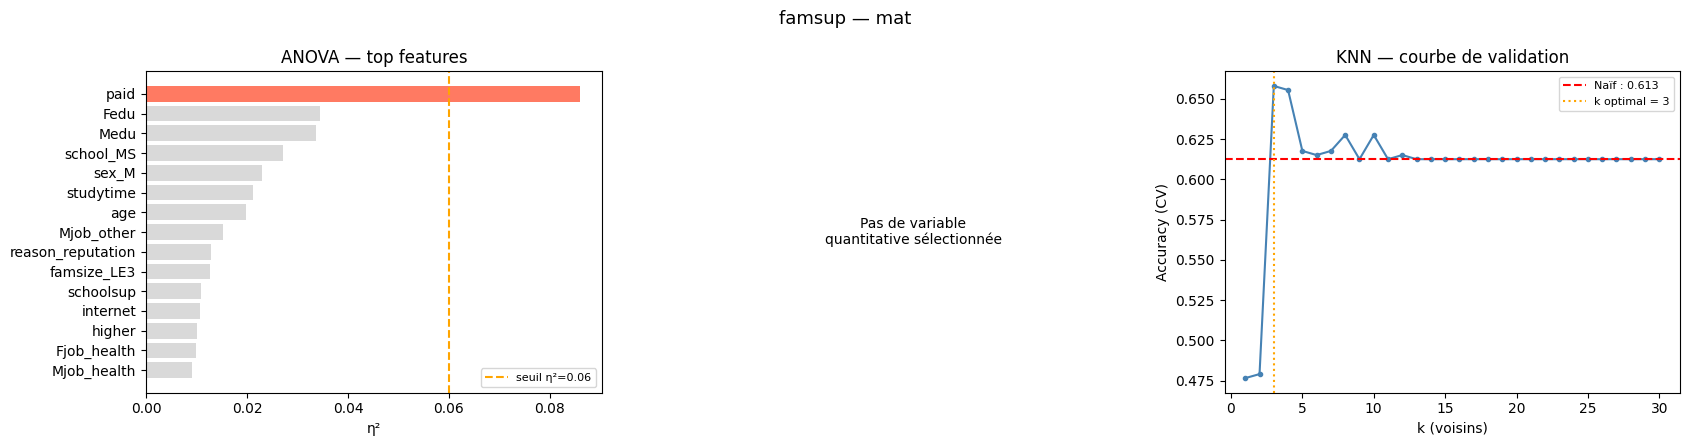

=== famsup (mat) — n=395, 2 classes, répartition : {0: np.int64(153), 1: np.int64(242)} ===
Features retenues (η² > 0.06) : ['paid']
Variables binaires parmi les sélectionnées : ['paid']

Naïf                  : 0.613
KNN (k= 3)         : 0.658
LDA (shrinkage='auto'): 0.633 ± 0.057
QDA (reg_param=0.1)   : 0.633 ± 0.057
Régression logistique : 0.633 ± 0.057


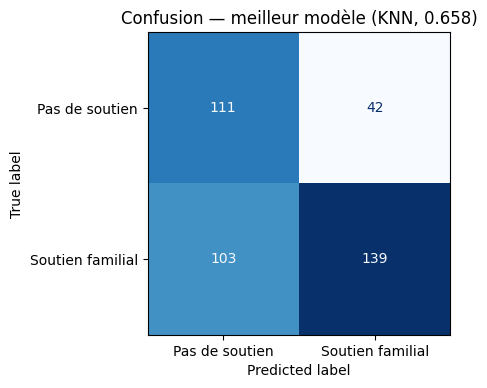

In [19]:
results.append(run_oracle_analysis(
    student_mat, y=(student_mat['famsup'] == 'yes').astype(int).values,
    target_label='famsup', dataset_label='mat', exclude_cols='famsup',
    class_names=['Pas de soutien', 'Soutien familial']
))

In [20]:
results.append(run_oracle_analysis(
    student_por, y=(student_por['famsup'] == 'yes').astype(int).values,
    target_label='famsup', dataset_label='por', exclude_cols='famsup',
    class_names=['Pas de soutien', 'Soutien familial']
))

=== famsup (por) — n=649, 2 classes ===
Aucune variable n'atteint le seuil η² > 0.06 (meilleure : 'studytime' avec η² = 0.021).
→ Signal prédictif quasi nul : on ne modélise pas, aucun modèle ne pourrait dépasser le naïf.
Naïf = 0.613



---
## 5. Cible : `activities` — activités extra-scolaires

Quasi parfaitement équilibrée (50.9% / 48.5%) — le cas le plus propre statistiquement (le naïf ne gagne quasiment rien).

In [21]:
results.append(run_oracle_analysis(
    student_mat, y=(student_mat['activities'] == 'yes').astype(int).values,
    target_label='activities', dataset_label='mat', exclude_cols='activities',
    class_names=['Pas d\'activités', 'Activités extra-scolaires']
))

=== activities (mat) — n=395, 2 classes ===
Aucune variable n'atteint le seuil η² > 0.06 (meilleure : 'reason_reputation' avec η² = 0.018).
→ Signal prédictif quasi nul : on ne modélise pas, aucun modèle ne pourrait dépasser le naïf.
Naïf = 0.509



In [23]:
results.append(run_oracle_analysis(
    student_por, y=(student_por['activities'] == 'yes').astype(int).values,
    target_label='activities', dataset_label='por', exclude_cols='activities',
    class_names=['Pas d\'activités', 'Activités extra-scolaires']
))

=== activities (por) — n=649, 2 classes ===
Aucune variable n'atteint le seuil η² > 0.06 (meilleure : 'freetime' avec η² = 0.023).
→ Signal prédictif quasi nul : on ne modélise pas, aucun modèle ne pourrait dépasser le naïf.
Naïf = 0.515



---
## 6. Cible : `romantic` — relation amoureuse

Déséquilibre modéré (33.4% / 36.8%) — premier vrai test de robustesse face à des classes inégales
(le naïf gagne déjà ~63-67%, donc l'accuracy seule ne suffira pas : on regardera aussi la matrice de confusion).

In [24]:
results.append(run_oracle_analysis(
    student_mat, y=(student_mat['romantic'] == 'yes').astype(int).values,
    target_label='romantic', dataset_label='mat', exclude_cols='romantic',
    class_names=['Célibataire', 'En couple']
))

=== romantic (mat) — n=395, 2 classes ===
Aucune variable n'atteint le seuil η² > 0.06 (meilleure : 'age' avec η² = 0.027).
→ Signal prédictif quasi nul : on ne modélise pas, aucun modèle ne pourrait dépasser le naïf.
Naïf = 0.666



In [25]:
results.append(run_oracle_analysis(
    student_por, y=(student_por['romantic'] == 'yes').astype(int).values,
    target_label='romantic', dataset_label='por', exclude_cols='romantic',
    class_names=['Célibataire', 'En couple']
))

=== romantic (por) — n=649, 2 classes ===
Aucune variable n'atteint le seuil η² > 0.06 (meilleure : 'age' avec η² = 0.032).
→ Signal prédictif quasi nul : on ne modélise pas, aucun modèle ne pourrait dépasser le naïf.
Naïf = 0.632



---
## 7. Cible : `paid` — cours particuliers payants (mat uniquement)

Sur `por`, seulement 6% de `yes` — le naïf gagnerait déjà à 94% sans rien apprendre, donc on se limite à `mat`
(45.8% / 54.2%, équilibre correct).

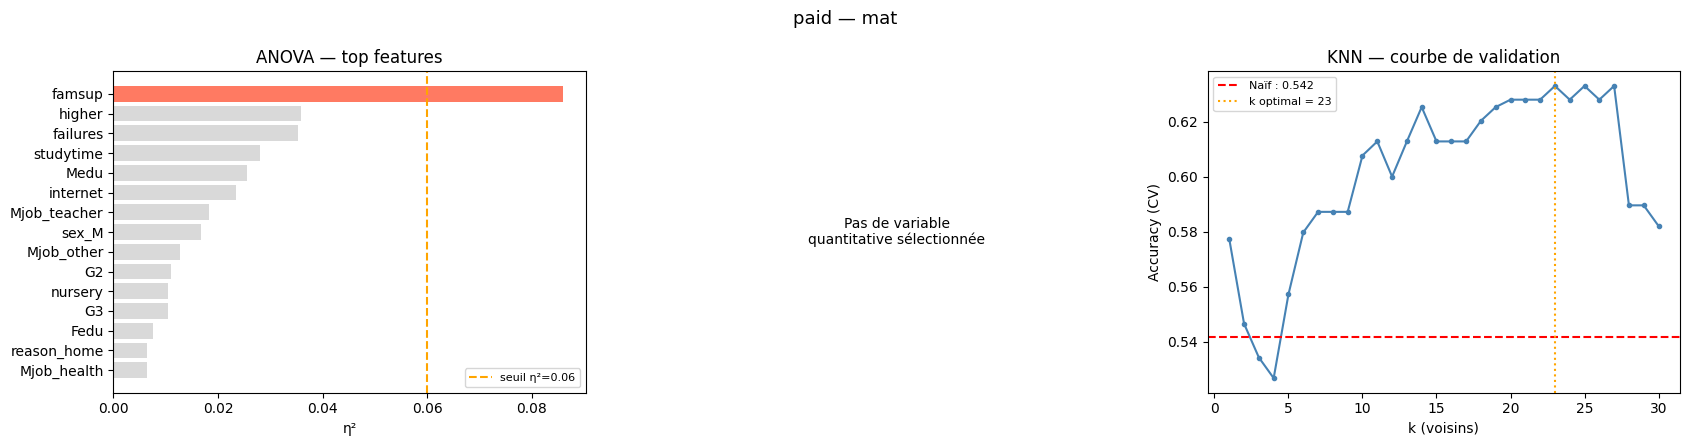

=== paid (mat) — n=395, 2 classes, répartition : {0: np.int64(214), 1: np.int64(181)} ===
Features retenues (η² > 0.06) : ['famsup']
Variables binaires parmi les sélectionnées : ['famsup']

Naïf                  : 0.542
KNN (k=23)         : 0.633
LDA (shrinkage='auto'): 0.633 ± 0.057
QDA (reg_param=0.1)   : 0.633 ± 0.057
Régression logistique : 0.633 ± 0.057


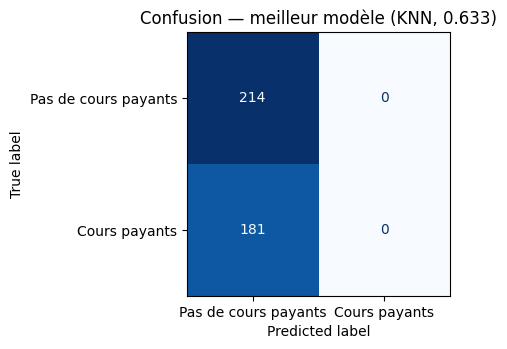

In [26]:
results.append(run_oracle_analysis(
    student_mat, y=(student_mat['paid'] == 'yes').astype(int).values,
    target_label='paid', dataset_label='mat', exclude_cols='paid',
    class_names=['Pas de cours payants', 'Cours payants']
))

---
## 8. Croisement `famsup` × `paid` (mat)

### Pourquoi ce croisement a du sens

`famsup` (aide aux devoirs par la famille) et `paid` (cours particuliers payants) sont deux formes de soutien scolaire
*a priori indépendantes* : une famille peut faire les deux, l'une, l'autre, ou ni l'une ni l'autre. Le croisement répond
à une vraie question : **« la famille soutient-elle l'élève, et sous quelle forme ? »** — plutôt qu'à une question
arbitraire (le croisement de deux variables sans lien logique n'aurait pas de sens à interpréter).

On construit donc une cible à 4 modalités à partir du produit cartésien `(famsup, paid)`.

In [27]:
cross_labels = {
    ('no',  'no'):  'Aucun soutien',
    ('no',  'yes'): 'Cours payants seuls',
    ('yes', 'no'):  'Aide familiale seule',
    ('yes', 'yes'): 'Soutien complet',
}
cross_key    = list(zip(student_mat['famsup'], student_mat['paid']))
cross_target = pd.Series([cross_labels[c] for c in cross_key])
cross_codes, cross_names = pd.factorize(cross_target, sort=True)

print("Effectifs par modalité :")
print(cross_target.value_counts())
print(f"\nTotal : {len(cross_target)}  —  plus petite modalité : {cross_target.value_counts().min()} individus")
print("Toutes les modalités ont un effectif suffisant (> 30) pour être modélisées.")

Effectifs par modalité :
Soutien complet         139
Aucun soutien           111
Aide familiale seule    103
Cours payants seuls      42
Name: count, dtype: int64

Total : 395  —  plus petite modalité : 42 individus
Toutes les modalités ont un effectif suffisant (> 30) pour être modélisées.


In [28]:
results.append(run_oracle_analysis(
    student_mat, y=cross_codes,
    target_label='famsup × paid', dataset_label='mat (croisement)',
    exclude_cols=['famsup', 'paid'], class_names=list(cross_names)
))

=== famsup × paid (mat (croisement)) — n=395, 4 classes ===
Aucune variable n'atteint le seuil η² > 0.06 (meilleure : 'Medu' avec η² = 0.053).
→ Signal prédictif quasi nul : on ne modélise pas, aucun modèle ne pourrait dépasser le naïf.
Naïf = 0.352



In [29]:
def best_acc(r):
    return max(r[m] for m in ['KNN', 'LDA', 'QDA', 'LogReg'])

famsup_mat = next(r for r in results if r['cible'] == 'famsup' and r['dataset'] == 'mat')
paid_mat   = next(r for r in results if r['cible'] == 'paid' and r['dataset'] == 'mat')
cross_mat  = next(r for r in results if r['cible'] == 'famsup × paid')

print("=== Croisement vs variables isolées (mat) ===")
print(f"famsup seul         : {best_acc(famsup_mat):.3f}  (naïf {famsup_mat['naive']:.3f}, 2 classes)")
print(f"paid seul           : {best_acc(paid_mat):.3f}  (naïf {paid_mat['naive']:.3f}, 2 classes)")
print(f"famsup × paid       : {best_acc(cross_mat):.3f}  (naïf {cross_mat['naive']:.3f}, {cross_mat['classes']} classes)")
print()
print(f"Gain du croisement vs famsup seul : {best_acc(cross_mat) - best_acc(famsup_mat):+.3f}")
print(f"Gain du croisement vs paid seul   : {best_acc(cross_mat) - best_acc(paid_mat):+.3f}")

=== Croisement vs variables isolées (mat) ===
famsup seul         : 0.658  (naïf 0.613, 2 classes)
paid seul           : 0.633  (naïf 0.542, 2 classes)
famsup × paid       : 0.352  (naïf 0.352, 4 classes)

Gain du croisement vs famsup seul : -0.306
Gain du croisement vs paid seul   : -0.281


---
## 9. Bilan global

        cible          dataset   n  classes  naive   KNN   LDA   QDA  LogReg     meilleur  meilleur_score  gain_vs_naif
         paid              mat 395        2  0.542 0.633 0.633 0.633   0.633          KNN           0.633         0.091
       famsup              mat 395        2  0.613 0.658 0.633 0.633   0.633          KNN           0.658         0.045
       famsup              por 649        2  0.613 0.613 0.613 0.613   0.613 aucun signal           0.613         0.000
   activities              mat 395        2  0.509 0.509 0.509 0.509   0.509 aucun signal           0.509         0.000
   activities              por 649        2  0.515 0.515 0.515 0.515   0.515 aucun signal           0.515         0.000
   activities              por 649        2  0.515 0.515 0.515 0.515   0.515 aucun signal           0.515         0.000
     romantic              mat 395        2  0.666 0.666 0.666 0.666   0.666 aucun signal           0.666         0.000
     romantic              por 649      

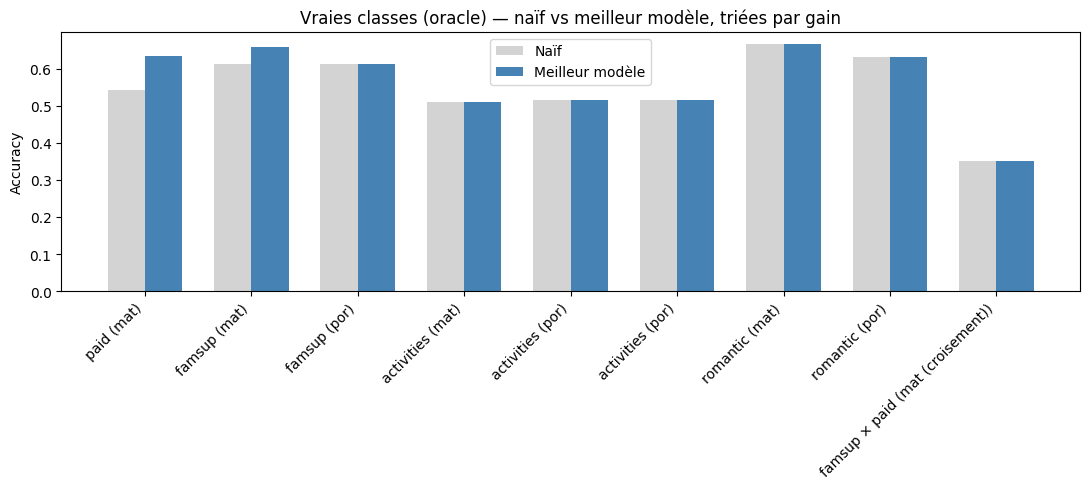

In [30]:
summary = pd.DataFrame(results)
for col in ['naive', 'KNN', 'LDA', 'QDA', 'LogReg']:
    summary[col] = summary[col].round(3)
summary['meilleur_score'] = summary[['KNN', 'LDA', 'QDA', 'LogReg']].max(axis=1).round(3)
summary['gain_vs_naif']   = (summary['meilleur_score'] - summary['naive']).round(3)
summary = summary.sort_values('gain_vs_naif', ascending=False).reset_index(drop=True)

display_cols = ['cible', 'dataset', 'n', 'classes', 'naive', 'KNN', 'LDA', 'QDA', 'LogReg',
                'meilleur', 'meilleur_score', 'gain_vs_naif']
print(summary[display_cols].to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 5))
labels_plot = summary['cible'] + ' (' + summary['dataset'] + ')'
x = np.arange(len(summary))
width = 0.35
ax.bar(x - width/2, summary['naive'], width, label='Naïf', color='lightgray')
ax.bar(x + width/2, summary['meilleur_score'], width, label='Meilleur modèle', color='steelblue')
ax.set_xticks(x); ax.set_xticklabels(labels_plot, rotation=45, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('Vraies classes (oracle) — naïf vs meilleur modèle, triées par gain')
ax.legend()
plt.tight_layout(); plt.show()

## 10. Conclusion

### Un résultat qui inverse complètement le message des notebooks précédents

Sur les clusters K-means, on atteignait 85-93% d'accuracy (LDA shrinkage, Régression logistique). Ici, sur de
**vraies** variables comportementales, le constat est presque l'opposé : **aucune des cibles isolées ne dépasse
significativement le modèle naïf**.

| Cible | Naïf | Meilleur modèle | Gain |
|---|---|---|---|
| `activities` (mat et por) | ~51% | ~51% | +0.000 |
| `romantic` (mat et por) | ~63-67% | ~63-67% | +0.000 |
| `famsup` (por) | 61.3% | 61.3% | +0.000 |
| `famsup × paid` (croisement, 4 classes) | 35.2% | 35.2% | +0.000 |
| `famsup` (mat) — prédit par `paid` | 61.3% | 65.8% | **+0.045** |
| `paid` (mat) — prédit par `famsup` | 54.2% | 63.3% | **+0.091** |

Pour 6 des 8 cibles testées, **l'ANOVA ne trouve même pas une seule variable franchissant le seuil η² > 0.06** :
le meilleur η² observé plafonne à 0.032 (`age` pour `romantic`/por). Aucun modèle — KNN, LDA, QDA ou régression
logistique — ne peut donc faire mieux que prédire la classe majoritaire : c'est mathématiquement impossible de
trouver un signal là où l'ANOVA elle-même n'en détecte aucun.

### Ce que ça révèle sur la nature des clusters K-means

Ce contraste est la vraie leçon de ce notebook : les clusters K-means n'étaient pas une structure « organique »
qu'on aurait découverte — ils sont en grande partie un **artefact géométrique de l'algorithme**, et notre capacité
à les « prédire » à 90% relevait d'un raisonnement en partie circulaire :

1. K-means construit ses groupes en minimisant la variance intra-cluster **dans l'espace ACP issu des 42 variables,
   y compris les variables booléennes elles-mêmes** (`famsup`, `paid`, `activities`, `romantic`...).
2. Re-prédire ces clusters à partir de ces mêmes 42 variables revient donc à demander : « les variables qui ont
   servi à construire le groupe permettent-elles de retrouver le groupe ? » — la réponse ne peut être que oui.

À l'inverse, demander « est-ce qu'une variable comportementale réelle (`romantic`, `activities`...) est *encodée*
dans le profil socio-démographique et scolaire d'un élève ? » est une question honnête, sans circularité — et la
réponse est : **non, quasiment pas**.

### La seule exception : `famsup` ↔ `paid`

Les deux seules variables qui se prédisent mutuellement un peu mieux que le hasard sont `famsup` (aide aux devoirs
par la famille) et `paid` (cours particuliers payants), sur `mat` uniquement (+4.5% et +9.1%). C'est cohérent : ce
sont deux formes concrètes et observables d'investissement parental dans la scolarité, qui partagent sans doute un
facteur latent commun (« la famille s'implique dans les études »).

Mais cette relation reste **faible**, et surtout : leur croisement (`famsup × paid`, 4 modalités — *aucun soutien /
aide familiale seule / cours payants seuls / soutien complet*) ne se prédit pas mieux que le hasard à partir du
reste du contexte (35.2% = naïf). Autrement dit, `famsup` et `paid` s'expliquent un peu l'une l'autre, mais ce
« profil de soutien familial combiné » n'est lui-même prédit par **aucune** autre variable — ni le capital éducatif
des parents (`Medu`/`Fedu`/`Mjob`/`Fjob`), ni la trajectoire scolaire (`failures`, `G1`/`G2`/`G3`), ni rien d'autre.

### Conclusion générale

Cette expérience ne valide pas une hypothèse qu'on pensait vérifier — elle en révèle une autre, plus intéressante :
les comportements réels des élèves (être en couple, faire des activités extra-scolaires, recevoir du soutien
scolaire) sont, dans ce dataset, **statistiquement indépendants** du profil scolaire et familial observable par
ailleurs (notes, origine sociale, trajectoire). La vie personnelle d'un élève n'est pas « lisible » dans son dossier
scolaire — et réciproquement.

Ce n'est pas un échec de méthode : la méthodologie (sélection ANOVA, vérification des hypothèses, comparaison
systématique de 4 familles de modèles) a parfaitement fonctionné, et a **correctement détecté l'absence de signal**
plutôt que de forcer un modèle à sur-apprendre du bruit. Repérer qu'il n'y a rien à prédire est, en soi, une
conclusion robuste — et elle éclaire rétrospectivement les résultats à 90% obtenus sur les clusters K-means : cette
performance mesurait la cohérence interne de l'algorithme de clustering, pas une quelconque prévisibilité du
comportement réel des élèves.